In [64]:
# Importation of necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score,cross_val_predict,train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score 
from sklearn.tree import DecisionTreeClassifier       

print("Libraries imported successfully!")

Libraries imported successfully!


In [65]:
# Loading the Titanic dataset
titanic_test = pd.read_csv('test.csv')
titanic_df = pd.read_csv('train.csv')
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [66]:
# Displaying the first few rows of the dataset
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [67]:
overall_survival_rate = titanic_df['Survived'].value_counts(normalize=True) * 100
overall_survival_rate 

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [68]:
survival_rate_by_sex = titanic_df.groupby('Sex')['Survived'].value_counts(normalize=True).unstack()* 100
survival_rate_by_sex

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [69]:
survival_rate_by_class = titanic_df.groupby('Pclass')['Survived'].value_counts(normalize=True).unstack() * 100
survival_rate_by_class

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


In [70]:
titanic_df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [71]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
891 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [72]:
survival_rate_by_age_group = titanic_df.groupby(pd.cut(titanic_df['Age'], bins=[0, 18, 80]))['Survived'].value_counts(normalize=True).unstack() * 100
survival_rate_by_age_group

C:\Users\HP\AppData\Local\Temp\ipykernel_6172\3440199474.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_age_group = titanic_df.groupby(pd.cut(titanic_df['Age'], bins=[0, 18, 80]))['Survived'].value_counts(normalize=True).unstack() * 100


Survived,0,1
Age,,
"(0, 18]",49.640288,50.359712
"(18, 80]",63.829787,36.170213


<Axes: xlabel='Sex', ylabel='Survived'>

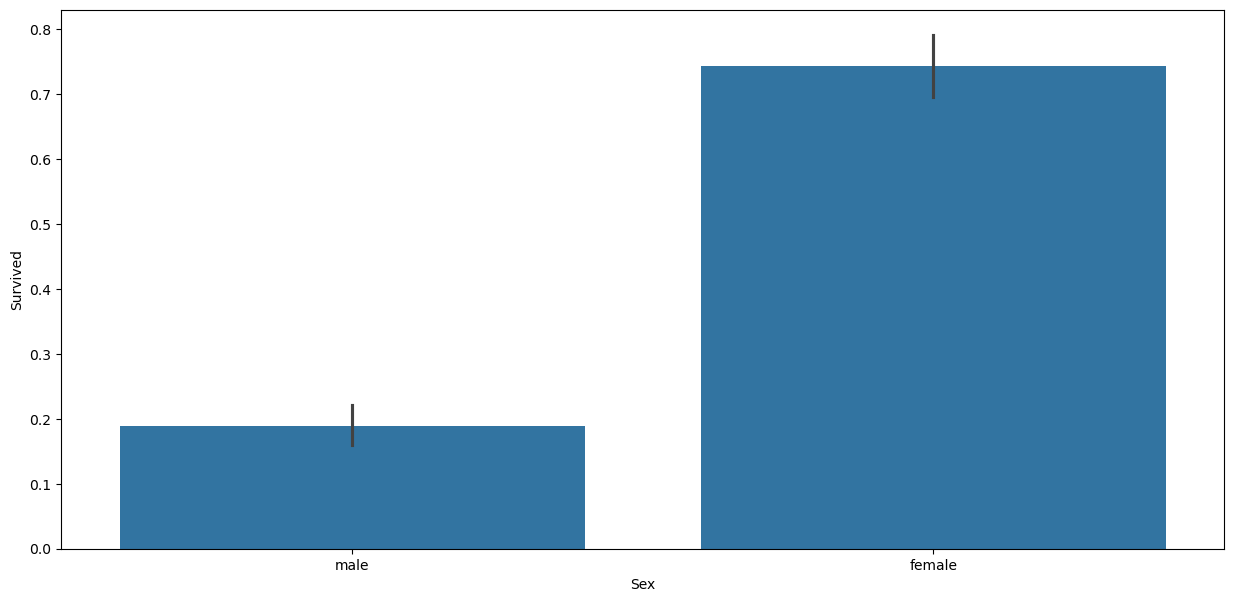

In [73]:
# Visualisation of survival rates by sex
plt.figure(figsize=(15, 7))
sns.barplot(x = 'Sex', y = 'Survived', data = titanic_df )

<Axes: xlabel='Pclass', ylabel='Survived'>

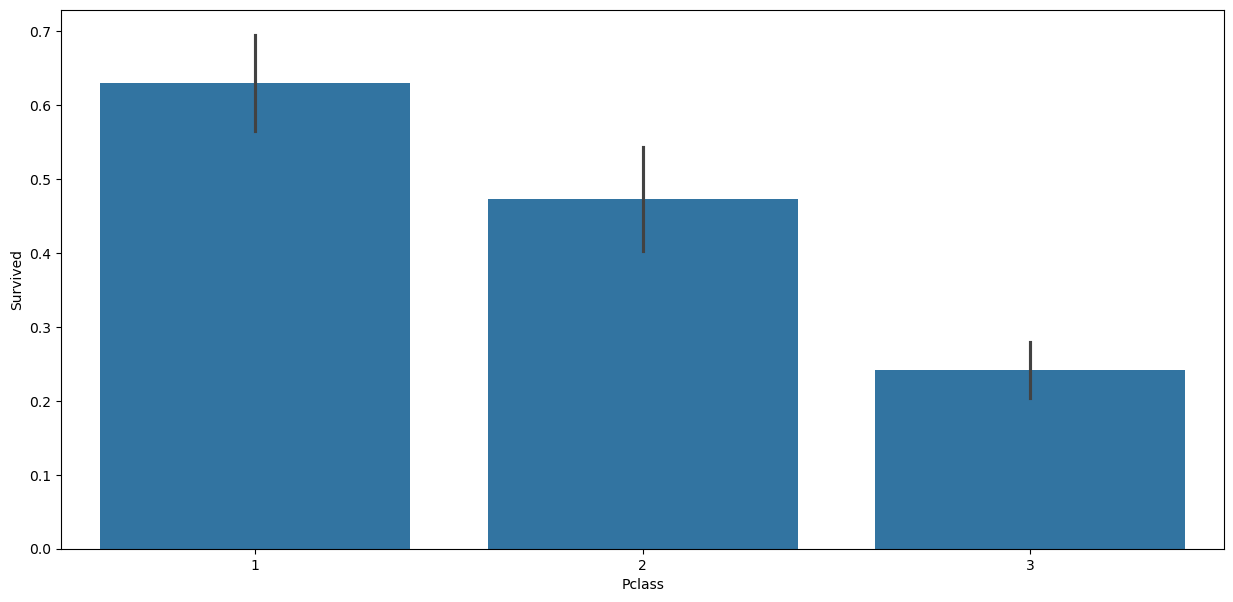

In [74]:
# Visualisation of survival rates by class
plt.figure(figsize=(15, 7))
sns.barplot(x = 'Pclass', y = 'Survived', data = titanic_df )

<Axes: xlabel='Age', ylabel='Survived'>

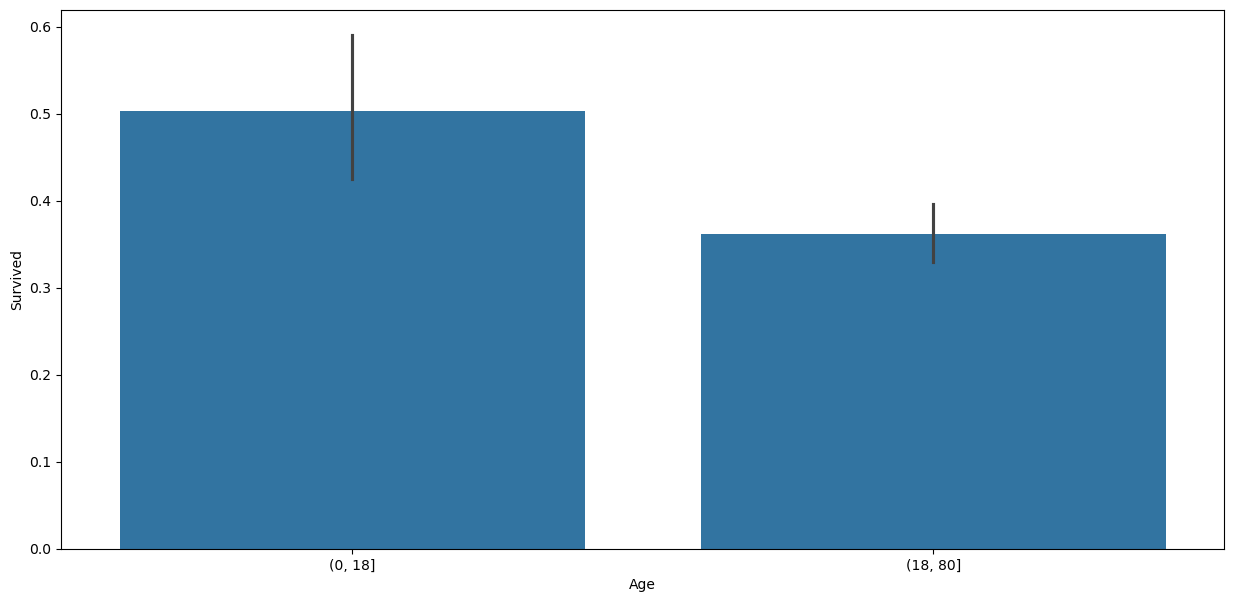

In [75]:
# Visualisation of survival rates by age group
plt.figure(figsize=(15, 7))
sns.barplot(x = pd.cut(titanic_df['Age'], bins=[0, 18, 80]), y = 'Survived', data = titanic_df )

Text(0, 0.5, 'Survival Rate')

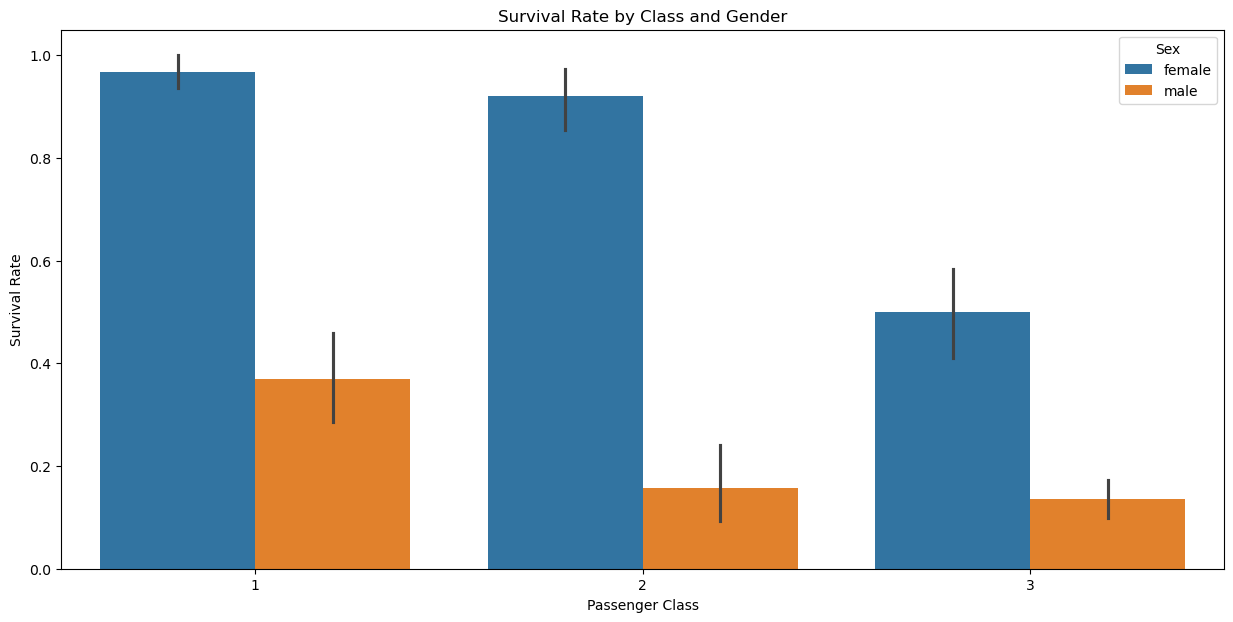

In [76]:
# Visualizing survival rate by class and gender
plt.figure(figsize=(15, 7))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)
plt.title("Survival Rate by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

In [77]:
# Cleaning of the columns Embarked
titanic_df['Embarked'].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [78]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('S')
titanic_df['Embarked'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Embarked
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [79]:
# Verifying the link between the Cabin and Pclass columns (correlation)
titanic_df.groupby('Pclass')['Cabin'].count()

Pclass
1    176
2     16
3     12
Name: Cabin, dtype: int64

In [80]:
# Cleaning of the columns Cabin
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknown')
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [81]:
# Extracting titles from the Name column
titanic_df['Title'] = titanic_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
titanic_df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [82]:
titanic_df['Title'] = titanic_df['Title'].replace(['Mlle'], 'Miss')
titanic_df['Title'] = titanic_df['Title'].replace(['Dr', 'Rev', 'Major', 'Col', 'Countess','Capt', 'Sir', 'Lady', 'Don', 'Jonkheer'], 'Rare')
titanic_df['Title'] = titanic_df['Title'].replace(['Mme','Ms'], 'Mrs')
titanic_df['Title'].value_counts()

Title
Mr        517
Miss      184
Mrs       127
Master     40
Rare       23
Name: count, dtype: int64

In [83]:
# creating a new column 'AgeGroup' based on the 'Age' column 
titanic_df['AgeGroup'] = pd.cut( titanic_df['Age'], bins = [0, 5, 18, 35, 60, 80])

In [84]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,"(18, 35]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,"(35, 60]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,"(18, 35]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,"(18, 35]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,"(18, 35]"


In [85]:
# encoding 'Sex' , 'Title', 'Embarked' and 'AgeGroup' columns
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1 })
titanic_df = pd.get_dummies(titanic_df, columns=['Title','Embarked'], dtype=int)
titanic_df = pd.get_dummies(titanic_df, columns=['AgeGroup'], drop_first=True, dtype=int)
titanic_df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_C,Embarked_Q,Embarked_S,"AgeGroup_(5, 18]","AgeGroup_(18, 35]","AgeGroup_(35, 60]","AgeGroup_(60, 80]"
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Unknown,0,0,1,0,0,0,0,1,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,0,0,0,1,0,1,0,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,0,1,0,0,0,0,0,1,0,1,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,0,0,1,0,0,0,1,0,1,0,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,Unknown,0,0,1,0,0,0,0,1,0,1,0,0
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,Unknown,0,0,1,0,0,0,1,0,0,1,0,0
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,17463,51.8625,E46,0,0,1,0,0,0,0,1,0,0,1,0
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,Unknown,1,0,0,0,0,0,0,1,0,0,0,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,Unknown,0,0,0,1,0,0,0,1,0,1,0,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,Unknown,0,0,0,1,0,1,0,0,1,0,0,0


In [86]:
# Creating a new feature 'FamilySize' and 'IsAlone'
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1
print(titanic_df['FamilySize'])
titanic_df['IsAlone'] = (titanic_df['FamilySize'] == 1).astype(int)
titanic_df.columns

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: FamilySize, Length: 891, dtype: int64


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Title_Master', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Embarked_C', 'Embarked_Q',
       'Embarked_S', 'AgeGroup_(5, 18]', 'AgeGroup_(18, 35]',
       'AgeGroup_(35, 60]', 'AgeGroup_(60, 80]', 'FamilySize', 'IsAlone'],
      dtype='object')

In [87]:
# Splitting the dataset into features and target variable
y = titanic_df['Survived']
features = ['Pclass', 'Sex', 'AgeGroup_(5, 18]', 'AgeGroup_(18, 35]', 'AgeGroup_(35, 60]', 'AgeGroup_(60, 80]', 'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Embarked_C', 'Embarked_Q',
       'Embarked_S' , 'Fare']
X = titanic_df[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [88]:
# Training the Random Forest Classifier model and evaluating it using cross-validation
model_df = RandomForestClassifier(n_estimators=100, max_depth=9, random_state=42, min_samples_leaf=5, min_samples_split=5)
scores = cross_val_score(model_df, X_train, y_train, cv=10)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())
model_df.fit(X_train, y_train)

Cross-validation scores: [0.86111111 0.81944444 0.76056338 0.94366197 0.85915493 0.74647887
 0.84507042 0.81690141 0.78873239 0.91549296]
Mean cross-validation score: 0.8356611893583723


,n_estimators,100
,criterion,'gini'
,max_depth,9
,min_samples_split,5
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
# Training prediction
train_predics = model_df.predict(X_test)
scores = accuracy_score(y_test, train_predics)
scores

0.8268156424581006

In [90]:
# Cleaning of the columns Cabin
titanic_test['Cabin'] = titanic_test['Cabin'].fillna('Unknown')

# Creating a new feature 'FamilySize'
titanic_test['FamilySize'] = titanic_test['SibSp'] + titanic_test['Parch'] + 1
titanic_test['IsAlone'] = (titanic_test['FamilySize'] == 1).astype(int)

# Extracting titles from the Name column
titanic_test['Title'] = titanic_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# creating a new column 'AgeGroup' based on the 'Age' column
titanic_test['AgeGroup'] = pd.cut( titanic_test['Age'], bins = [0, 5, 18, 35, 60, 80])

# Replacing rare titles with 'Rare' and standardizing other titles
titanic_test['Title'] = titanic_test['Title'].replace(['Mlle'], 'Miss')
titanic_test['Title'] = titanic_test['Title'].replace(['Dr', 'Rev', 'Major', 'Col', 'Countess','Capt', 'Sir', 'Lady', 'Dona', 'Jonkheer'], 'Rare')
titanic_test['Title'] = titanic_test['Title'].replace(['Mme','Ms'], 'Mrs')

# Encoding the 'Sex','Title' and 'Embarked' columns
titanic_test['Sex'] = titanic_test['Sex'].map({'male': 0, 'female': 1 })
titanic_test = pd.get_dummies(titanic_test, columns=['Title','Embarked'], dtype=int)
titanic_test = pd.get_dummies(titanic_test, columns=['AgeGroup'], drop_first=True, dtype=int)
titanic_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,IsAlone,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_C,Embarked_Q,Embarked_S,"AgeGroup_(5, 18]","AgeGroup_(18, 35]","AgeGroup_(35, 60]","AgeGroup_(60, 80]"
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,Unknown,1,1,0,0,1,0,0,0,1,0,0,1,0,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,Unknown,2,0,0,0,0,1,0,0,0,1,0,0,1,0
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,Unknown,1,1,0,0,1,0,0,0,1,0,0,0,0,1
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,Unknown,1,1,0,0,1,0,0,0,0,1,0,1,0,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,Unknown,3,0,0,0,0,1,0,0,0,1,0,1,0,0


In [91]:
# Prepare test data for prediction
X_test_kaggle = titanic_test.drop(columns=['PassengerId','Parch','SibSp','Cabin','Ticket','Name'])
X_test_kaggle.head()

,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_C,Embarked_Q,Embarked_S,"AgeGroup_(5, 18]","AgeGroup_(18, 35]","AgeGroup_(35, 60]","AgeGroup_(60, 80]"
0,3,0,34.5,7.8292,1,1,0,0,1,0,0,0,1,0,0,1,0,0
1,3,1,47.0,7.0000,2,0,0,0,0,1,0,0,0,1,0,0,1,0
2,2,0,62.0,9.6875,1,1,0,0,1,0,0,0,1,0,0,0,0,1
3,3,0,27.0,8.6625,1,1,0,0,1,0,0,0,0,1,0,1,0,0
4,3,1,22.0,12.2875,3,0,0,0,0,1,0,0,0,1,0,1,0,0


In [92]:
predictions_kaggle = model_df.predict(X_test_kaggle[features])
submission_data = {'PassengerId': titanic_test['PassengerId'], 
                   'Survived': predictions_kaggle
                   }
submission_titanic = pd.DataFrame(submission_data)
submission_titanic.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [97]:
submission_titanic.to_csv('submission_titanic.csv', index=False)
print("Submission file created successfully!")

Submission file created successfully!


In [98]:
import joblib
joblib.dump(model_df, 'titanic_model.joblib')

['titanic_model.joblib']